## Importing important libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## Loading the dataset

In [2]:
df = pd.read_csv("Data/weatherhistory.zip")
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


# Exploratory Data Analysis (EDA)

## Understanding the data

In [3]:
df.shape

(96453, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [5]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


## Handling missing values

In [6]:
df.isna().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.shape

(95936, 12)

In [9]:
df.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

## Retaining numerical columns only

In [10]:
num_df = df.select_dtypes(exclude="object")

In [11]:
num_df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51


In [12]:
num_df = num_df.drop("Apparent Temperature (C)", axis=1) #Two temperature columns is not required.
X = num_df["Humidity"]
Y = num_df["Temperature (C)"]

## Outlier Detection

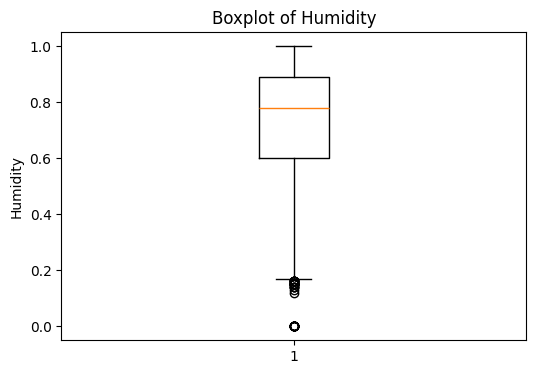

In [13]:
plt.figure(figsize=(6,4))
plt.boxplot(X)

plt.title("Boxplot of Humidity")
plt.ylabel("Humidity")
plt.show()

In [14]:
col = "Humidity"

Q1 = num_df[col].quantile(0.25)
Q3 = num_df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (num_df[col] >= lower) & (num_df[col] <= upper)
outliers = (num_df[col] < lower) & (num_df[col] > upper)

X = num_df.loc[mask, ["Humidity"]]
Y = num_df.loc[mask, "Temperature (C)"]

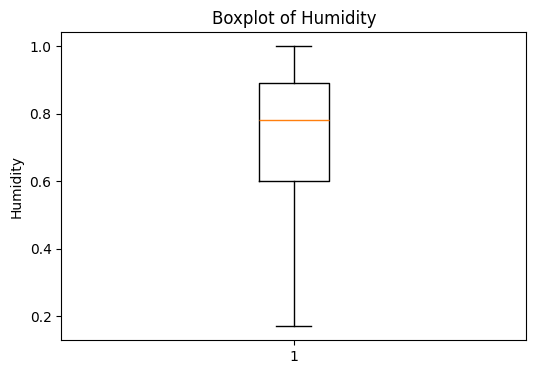

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(X)

plt.title("Boxplot of Humidity")
plt.ylabel("Humidity")
plt.show()

## Simple Linear Regression (without feature scaling)

In [16]:
les = LinearRegression()
X = X.values.reshape(-1, 1)
les.fit(X,Y)
pred_Y = les.predict(X)

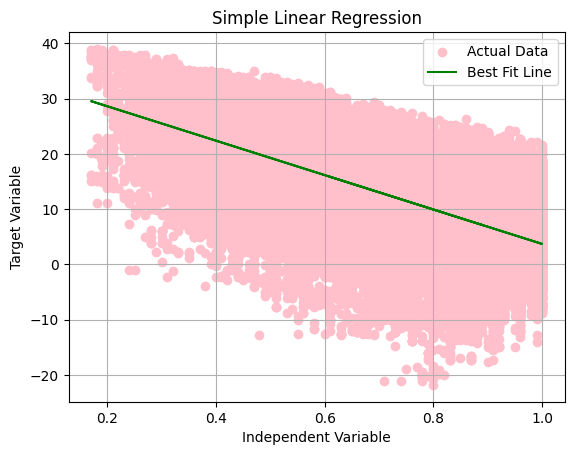

In [17]:
plt.scatter(X, Y, color="pink", label="Actual Data")
plt.plot(X, pred_Y, color="green", label="Best Fit Line")

plt.xlabel("Independent Variable")
plt.ylabel("Target Variable")
plt.title("Simple Linear Regression")
plt.grid()
plt.legend()

plt.show()

In [18]:
print("MSE: ", mean_squared_error(Y, pred_Y))
print("RMSE: ", root_mean_squared_error(Y, pred_Y))
print("MAE: ", mean_absolute_error(Y, pred_Y))
print("R2 Score: ", r2_score(Y, pred_Y))

MSE:  54.43749375435016
RMSE:  7.378176858435298
MAE:  6.036787588820917
R2 Score:  0.4042190284669782


## Simple Linear Regression with feature scaling and train_test_split

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.fit_transform(X_test)

Why we scale after splitting?

If you do: You are letting the model see the information from the test set. This is called data leakage.

Why do we not scale Y:

You only scale: Continuous input features (X)

You don't scale: Target variable


In [20]:
le2 = LinearRegression()
le2.fit(X_train, Y_train)
pred_Y = le2.predict(X_test)

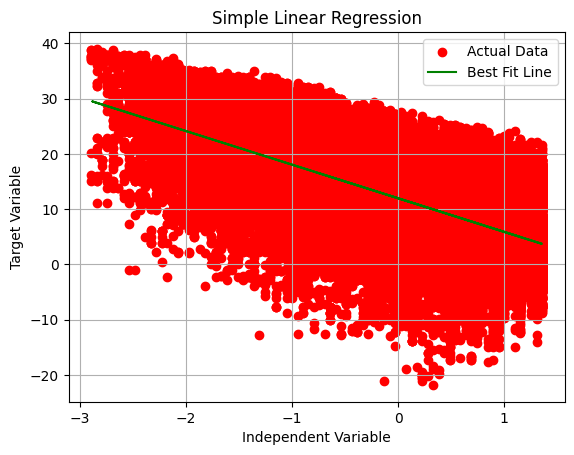

In [21]:
plt.scatter(X_train, Y_train, color="red", label="Actual Data")
plt.plot(X_test, pred_Y, color="green", label="Best Fit Line")

plt.xlabel("Independent Variable")
plt.ylabel("Target Variable")
plt.title("Simple Linear Regression")
plt.grid()
plt.legend()

plt.show()

In [22]:
print("MSE: ", mean_squared_error(Y_test, pred_Y))
print("RMSE: ", root_mean_squared_error(Y_test, pred_Y))
print("MAE: ", mean_absolute_error(Y_test, pred_Y))
print("R2 Score: ", r2_score(Y_test, pred_Y))

MSE:  55.20783509197205
RMSE:  7.43019751365817
MAE:  6.064102267513499
R2 Score:  0.40121487251025834


## Multiple Linear Regression (not included for your MidSems)

In [23]:
X = num_df.drop("Temperature (C)", axis=1)
Y = num_df["Temperature (C)"]

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
s = StandardScaler()
X_train = s.fit_transform(X_train)
X_test = s.fit_transform(X_test)

In [25]:
le = LinearRegression()
le.fit(X_train, Y_train)
pred_Y = le.predict(X_test)

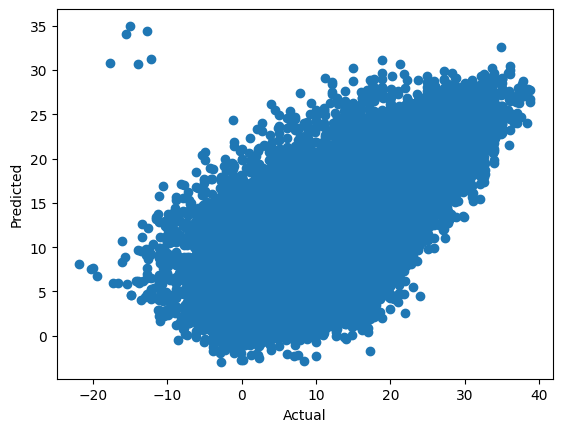

In [26]:
plt.scatter(Y_test, pred_Y)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [27]:
print("MSE: ", mean_squared_error(Y_test, pred_Y))
print("RMSE: ", root_mean_squared_error(Y_test, pred_Y))
print("MAE: ", mean_absolute_error(Y_test, pred_Y))
print("R2 Score: ", r2_score(Y_test, pred_Y))

MSE:  50.430776504883426
RMSE:  7.101462983419926
MAE:  5.676326776189992
R2 Score:  0.44692405030109195


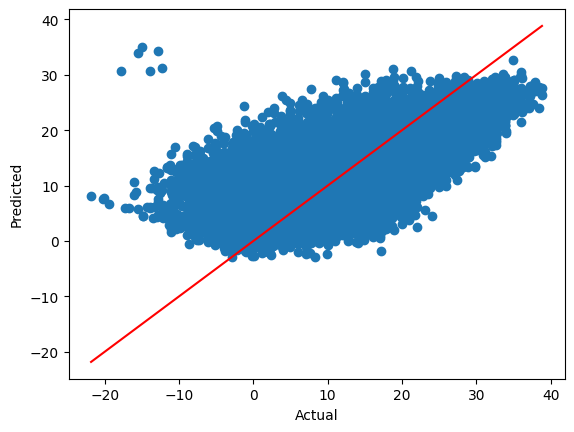

In [28]:
import numpy as np

plt.scatter(Y_test,pred_Y)
plt.plot([min(Y_test), max(Y_test)],
         [min(Y_test), max(Y_test)],
         color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()